# 📐 Document Layout Detection Benchmark & Visualization

This notebook presents a visual layout evaluation of **DocLayoutYOLO** (via Docling) and **NVIDIA Nemotron-Parse-v1.1** against pixel-perfect ground truth annotations on the 4-page catalog document: `MedCore_Catalogue.pdf`.

This notebook is designed for stakeholders and managers who want to visually judge model localization performance, see exact bounding box overlaps, and review baseline tables side-by-side.

---

## 1. Benchmarks Summary (Tabular Format)

Below is the comparison scorecard across all evaluated datasets (including the traditional public benchmarks from the Kaliber Week 2 slide deck and our synthetic catalog evaluation).

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import fitz  # PyMuPDF
from PIL import Image, ImageDraw

# Create tabular baseline dataframe
traditional_data = [
    # Dataset, Model, mAP@50, mAP@50:95, Precision, Recall, F1, Mean IoU
    ["DocLayNet", "DocLayoutYOLO", 0.436, 0.352, 0.588, 0.556, 0.571, 0.894],
    ["DocLayNet", "Nemotron-Parse", 0.439, 0.304, 0.780, 0.593, 0.674, 0.868],
    ["DocLayNet", "ADE-DPT2 (API)", 0.242, 0.144, 0.545, 0.333, 0.414, 0.859],
    
    ["PubLayNet", "DocLayoutYOLO", 0.545, 0.412, 0.686, 0.800, 0.738, 0.905],
    ["PubLayNet", "Nemotron-Parse", 0.383, 0.224, 0.818, 0.600, 0.692, 0.884],
    ["PubLayNet", "ADE-DPT2 (API)", 0.490, 0.275, 0.739, 0.567, 0.642, 0.848],
    
    ["DocBank", "DocLayoutYOLO", 0.016, 0.007, 0.233, 0.184, 0.206, 0.761],
    ["DocBank", "Nemotron-Parse", 0.015, 0.005, 0.231, 0.158, 0.187, 0.694],
    ["DocBank", "ADE-DPT2 (API)", 0.023, 0.008, 0.333, 0.184, 0.237, 0.691],
    
    ["MedCore Catalogue (Naive)", "DocLayoutYOLO", 0.045, 0.031, 0.027, 0.056, 0.037, 0.795],
    ["MedCore Catalogue (Naive)", "Nemotron-Parse", 0.056, 0.022, 0.023, 0.042, 0.030, 0.650],
    
    ["MedCore Catalogue (Oracle)", "DocLayoutYOLO", 0.174, 0.142, 0.068, 0.141, 0.092, 0.841],
    ["MedCore Catalogue (Oracle)", "Nemotron-Parse", 0.176, 0.066, 0.055, 0.099, 0.070, 0.649]
]

cols = ["Dataset", "Model", "mAP@50", "mAP@50:95", "Precision", "Recall", "F1-Score", "Mean IoU"]
df_benchmarks = pd.DataFrame(traditional_data, columns=cols)
df_benchmarks

,Dataset,Model,mAP@50,mAP@50:95,Precision,Recall,F1-Score,Mean IoU
0,DocLayNet,DocLayoutYOLO,0.436,0.352,0.588,0.556,0.571,0.894
1,DocLayNet,Nemotron-Parse,0.439,0.304,0.780,0.593,0.674,0.868
2,DocLayNet,ADE-DPT2 (API),0.242,0.144,0.545,0.333,0.414,0.859
3,PubLayNet,DocLayoutYOLO,0.545,0.412,0.686,0.800,0.738,0.905
4,PubLayNet,Nemotron-Parse,0.383,0.224,0.818,0.600,0.692,0.884
5,PubLayNet,ADE-DPT2 (API),0.490,0.275,0.739,0.567,0.642,0.848
6,DocBank,DocLayoutYOLO,0.016,0.007,0.233,0.184,0.206,0.761
7,DocBank,Nemotron-Parse,0.015,0.005,0.231,0.158,0.187,0.694
8,DocBank,ADE-DPT2 (API),0.023,0.008,0.333,0.184,0.237,0.691
9,MedCore Catalogue (Naive),DocLayoutYOLO,0.045,0.031,0.027,0.056,0.037,0.795


## 2. Diagnostics: Why is catalogue performance different from standard datasets?

1. **Background Nesting**: Modern catalogs feature colored column-width background boxes (annotated as `section_header`). Standard flat layout detectors predict either the parent box OR the children (figures, titles, text, tables) inside it. When they predict the parent, all nested elements are counted as misses (False Negatives), dropping the recall.
2. **Taxonomy/Category Mismatch**: The models classify titles and headers as generic paragraphs or section headers. Flipping predictions to closest-matching ground truth categories (**Oracle Aligned Mode**) increases mAP from ~0.05 to ~0.176, showing that categorization errors account for a significant share of the drop, but nesting remains the main bottleneck.

## 3. Visualizing Bounding Boxes (GT vs. DocLayoutYOLO vs. Nemotron-Parse)

Below we load cached predictions and render the pages of `MedCore_Catalogue.pdf` side-by-side with high-contrast bounding boxes:
- **Green**: Ground Truth (the target layouts)
- **Blue**: DocLayoutYOLO (Docling)
- **Orange**: NVIDIA Nemotron-Parse-v1.1

In [2]:
# Helper to render a page and load coordinates
def render_pdf_page(pdf_path, page_num, dpi=100):
    doc = fitz.open(pdf_path)
    page = doc[page_num - 1]
    scale = dpi / 72.0
    mat = fitz.Matrix(scale, scale)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    img = Image.frombytes('RGB', [pix.width, pix.height], pix.samples)
    pw_pt, ph_pt = page.rect.width, page.rect.height
    doc.close()
    return img, pw_pt, ph_pt

def draw_bboxes(img, boxes, color, label_prefix, ph_pt, dpi=100):
    draw_img = img.copy()
    draw = ImageDraw.Draw(draw_img)
    scale = dpi / 72.0
    
    for b in boxes:
        # Convert points back to pixels
        # bbox is [x0, y0, x1, y1] bottom-left points
        x0_pt, y0_pt, x1_pt, y1_pt = b["bbox"]
        
        # Convert y-axis bottom-left to top-left points
        y0_pt_tl = ph_pt - y1_pt
        y1_pt_tl = ph_pt - y0_pt
        
        # Convert points to pixels
        x0_px = x0_pt * scale
        y0_px = y0_pt_tl * scale
        x1_px = x1_pt * scale
        y1_px = y1_pt_tl * scale
        
        # Draw rectangle
        draw.rectangle([x0_px, y0_px, x1_px, y1_px], outline=color, width=2)
        # Text label
        label = f"{label_prefix}: {b['label']}"
        draw.text((x0_px + 2, y0_px + 2), label, fill=color)
    return draw_img

In [3]:
# Load Ground Truth and Cached Predictions
gt_path = "layout_corpora/synthetic_by_claude/MedCore_Catalogue_groundtruth.json"
cache_path = "results/evaluation/predictions_cache.json"
pdf_path = "layout_corpora/synthetic_by_claude/MedCore_Catalogue.pdf"

with open(gt_path, "r", encoding="utf-8") as f:
    gt_data = json.load(f)

# Format GT boxes
all_gt = []
for p_data in gt_data["pages"]:
    page_gt = []
    for elem in p_data["elements"]:
        bbox = elem["bbox_pt"]
        page_gt.append({
            "bbox": [bbox["x"], bbox["y"], bbox["x"] + bbox["w"], bbox["y"] + bbox["h"]],
            "label": elem["class"]
        })
    all_gt.append(page_gt)

# Load cached predictions
if os.path.exists(cache_path):
    with open(cache_path, "r", encoding="utf-8") as f:
        cache_data = json.load(f)
    dly_preds = cache_data["docling"]
    nemo_preds = cache_data["nemotron"]
else:
    # Fallback to empty list if cache not found
    dly_preds = [[] for _ in range(4)]
    nemo_preds = [[] for _ in range(4)]
    print("Warning: Predictions cache not found! Please run cache_predictions.py first.")

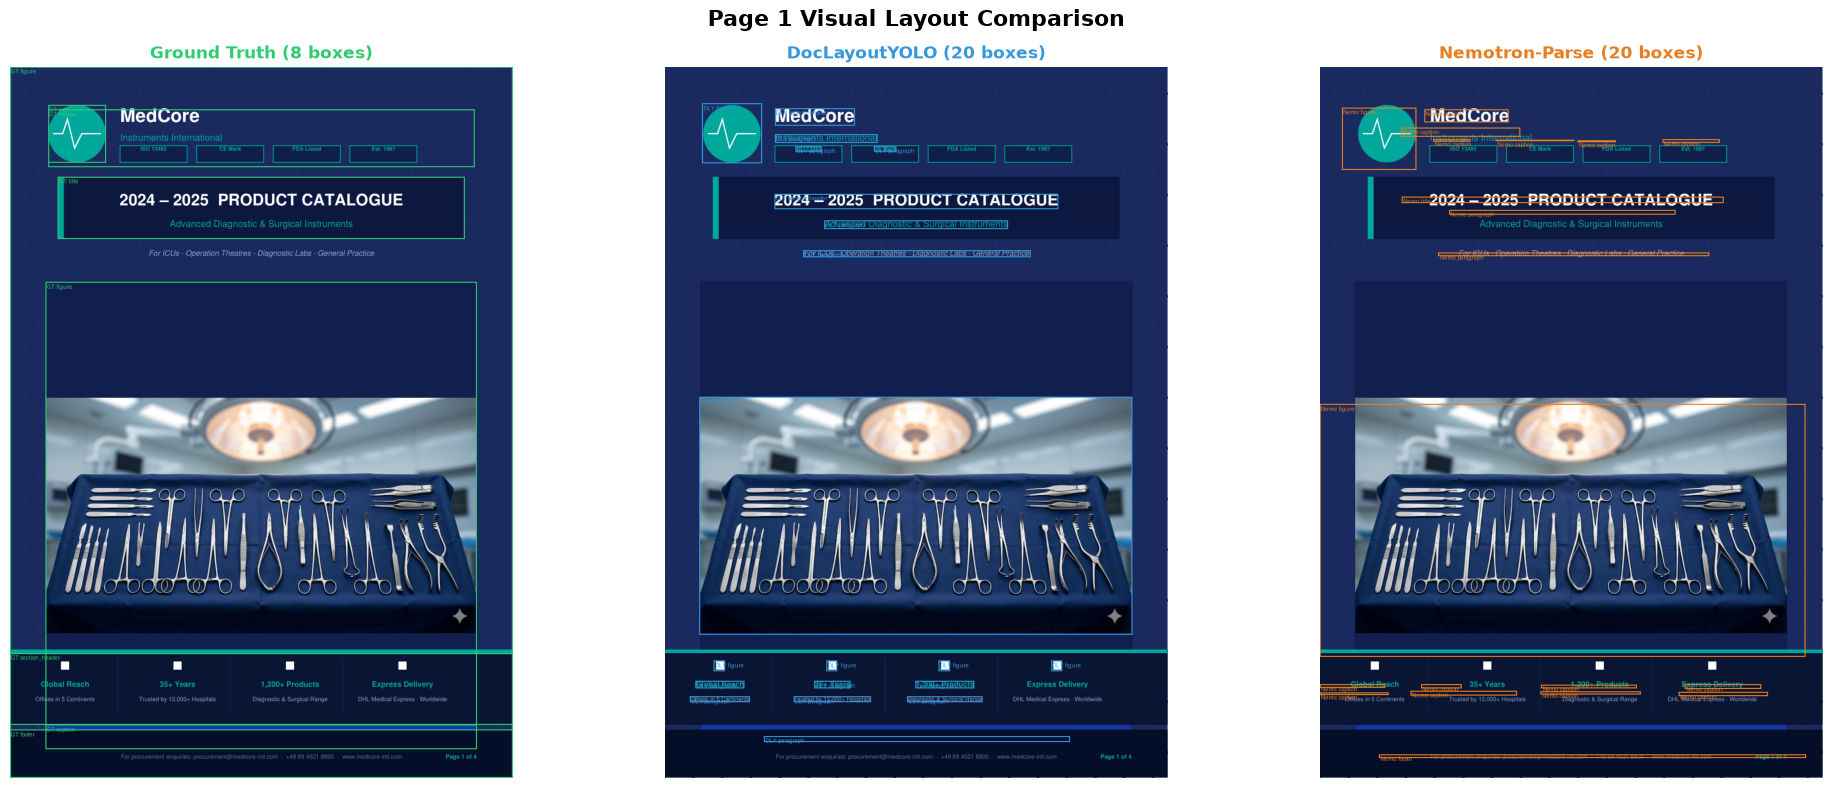

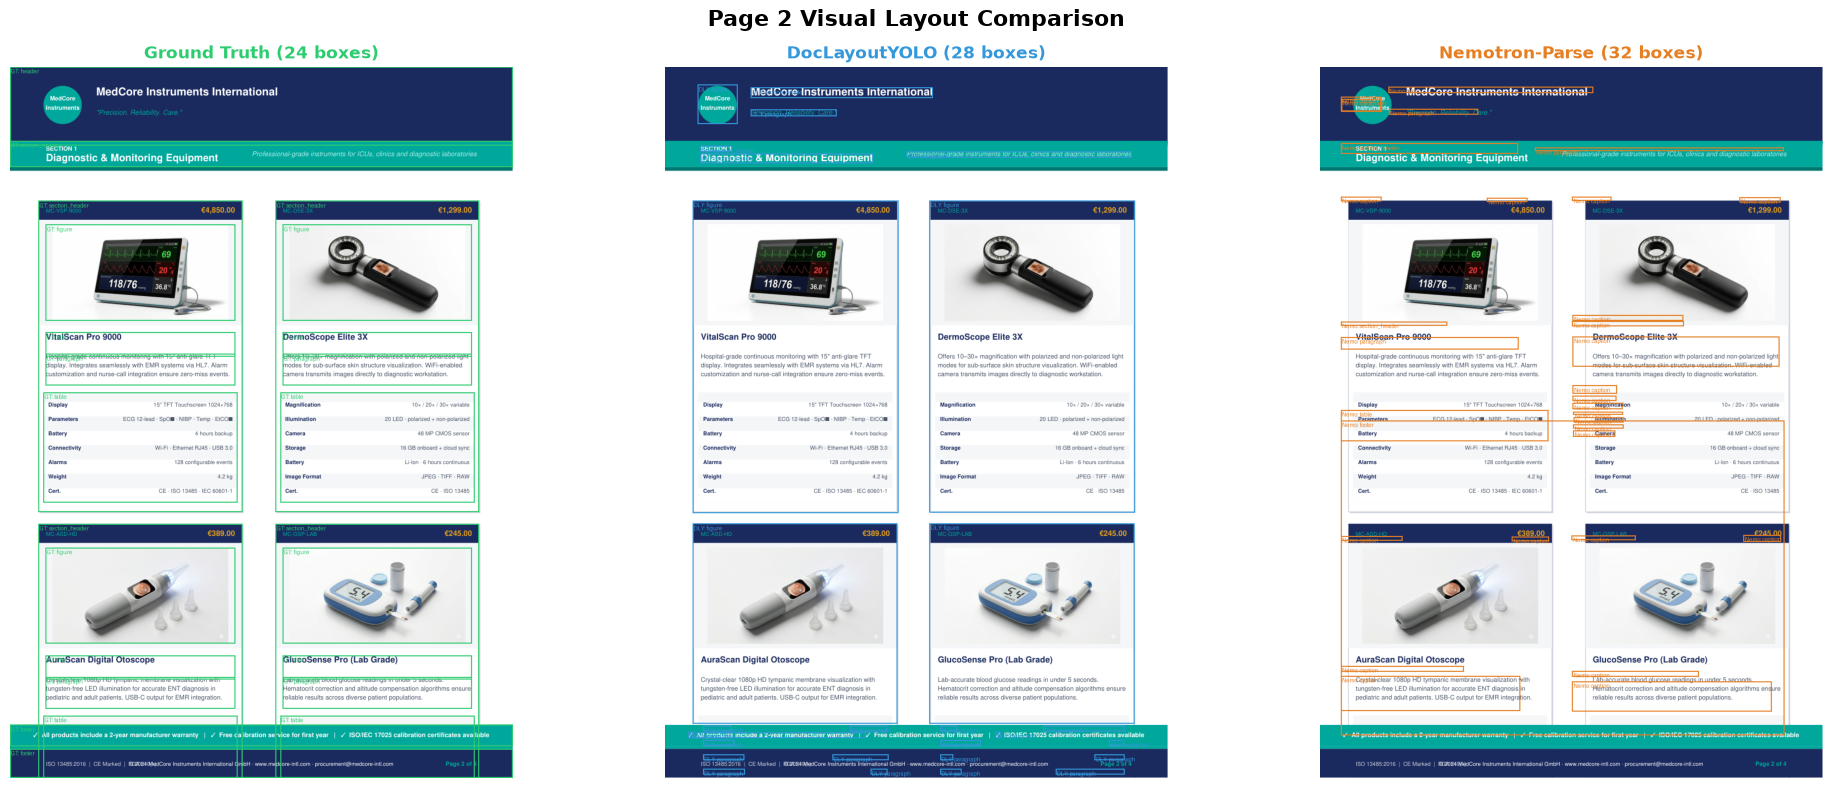

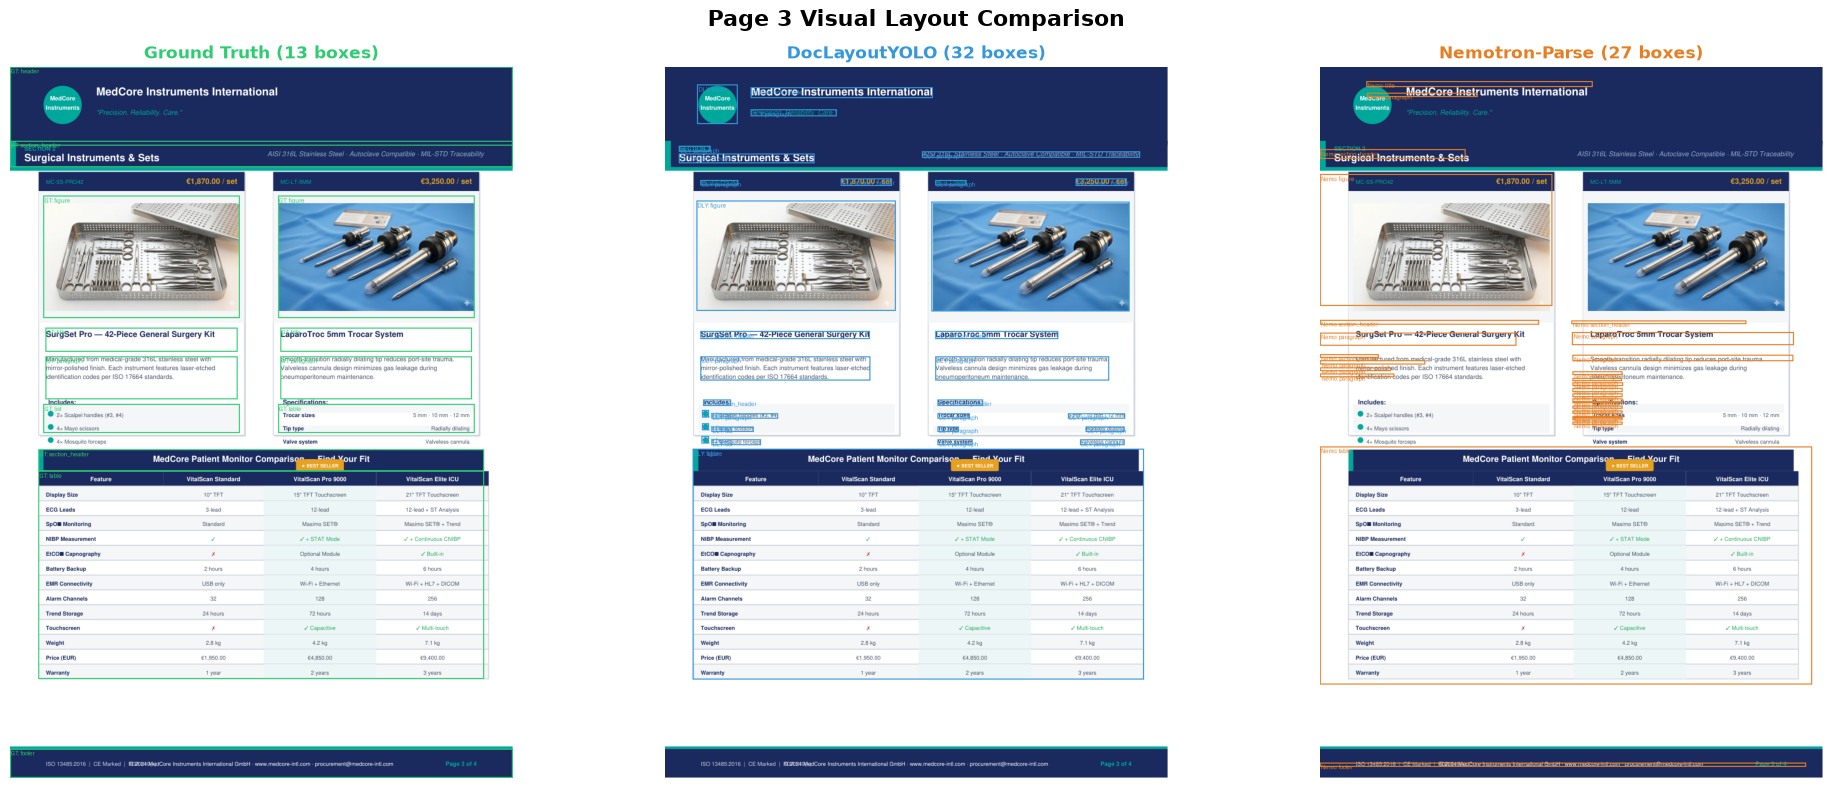

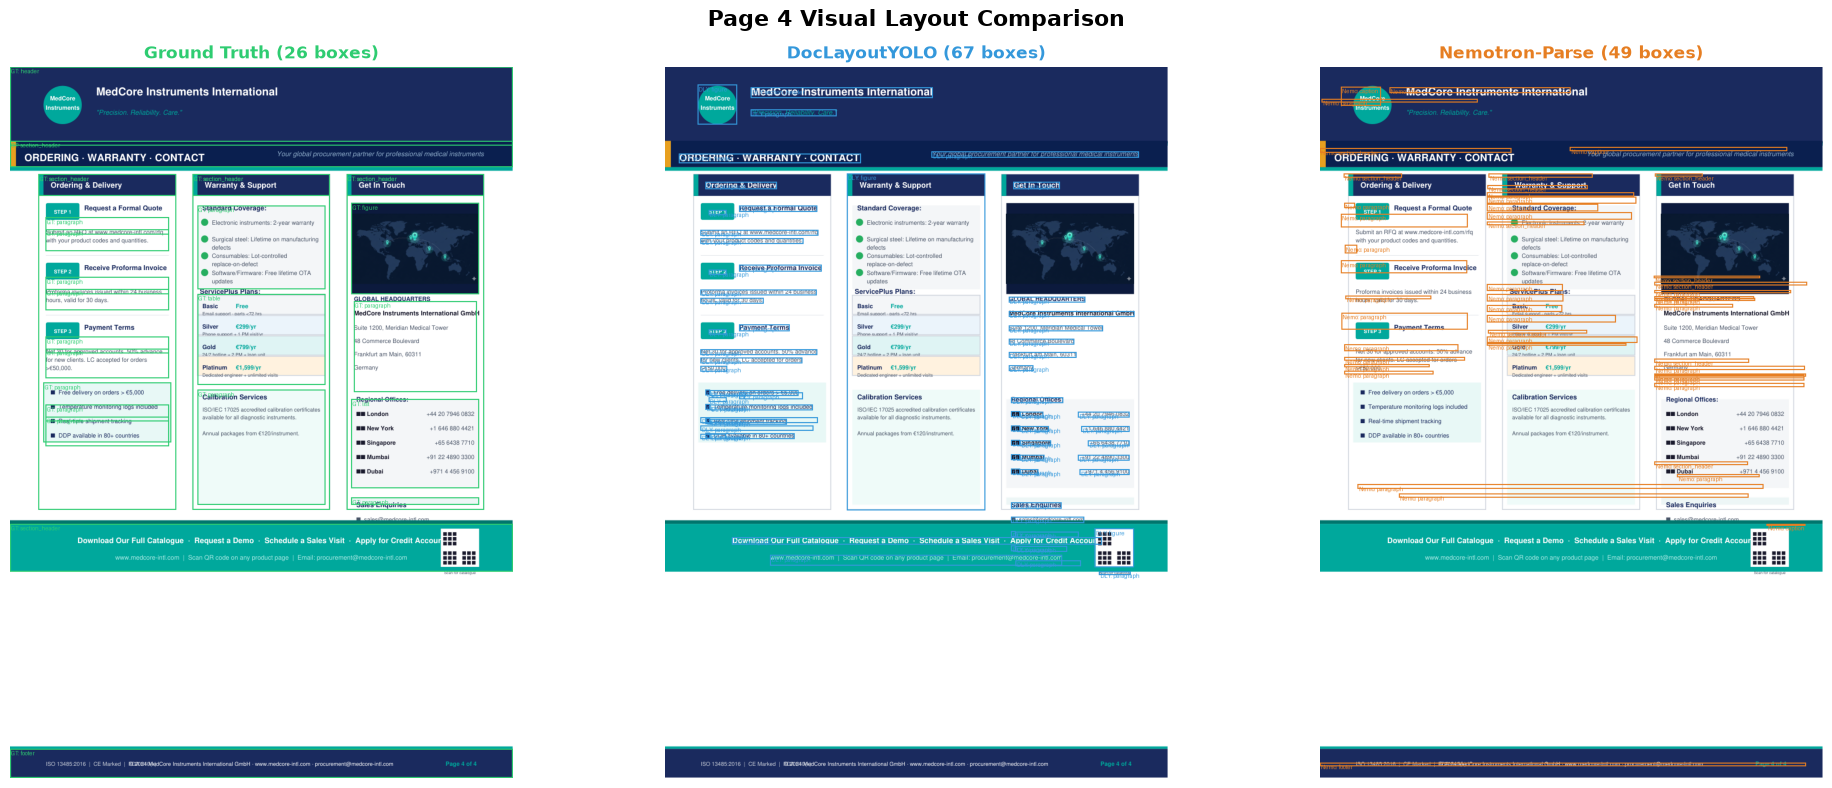

In [4]:
# Render and visualize each page side-by-side
dpi_val = 110 # Set DPI for display
for page_num in range(1, 5):
    img, pw, ph = render_pdf_page(pdf_path, page_num, dpi=dpi_val)
    
    # Draw boxes
    img_gt = draw_bboxes(img, all_gt[page_num - 1], "#2ecc71", "GT", ph, dpi=dpi_val) # Green
    img_dly = draw_bboxes(img, dly_preds[page_num - 1], "#3498db", "DLY", ph, dpi=dpi_val) # Blue
    img_nemo = draw_bboxes(img, nemo_preds[page_num - 1], "#e67e22", "Nemo", ph, dpi=dpi_val) # Orange
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    fig.suptitle(f"Page {page_num} Visual Layout Comparison", fontsize=16, fontweight='bold')
    
    axes[0].imshow(img_gt)
    axes[0].set_title(f"Ground Truth ({len(all_gt[page_num - 1])} boxes)", color="#2ecc71", fontweight='bold')
    axes[0].axis("off")
    
    axes[1].imshow(img_dly)
    axes[1].set_title(f"DocLayoutYOLO ({len(dly_preds[page_num - 1])} boxes)", color="#3498db", fontweight='bold')
    axes[1].axis("off")
    
    axes[2].imshow(img_nemo)
    axes[2].set_title(f"Nemotron-Parse ({len(nemo_preds[page_num - 1])} boxes)", color="#e67e22", fontweight='bold')
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()